# Nulos a gestionar

- ** Age ** -> Tiene 5120 nulos. 
- ** job ** -> Tiene 345 nulos. 
- ** eduction ** -> Tiene 1807 nulos. 
- ** default ** -> Tiene 8981 nulos. 
- ** housing ** -> Tiene 1026 nulos.
- ** loan ** -> Tiene 1026 nulos.
- ** cons.price.idx ** -> Tiene 471 nulos. 
- ** euribor3m ** -> Tiene 9256 nulos. 
- ** date ** -> Tiene 248 nulos. 

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer


In [20]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.1 MB 27.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 19.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.0 MB 51.2 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 23.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
df_o = pd.read_csv('../data/data_limpios.csv')
df_o.sample()


,Unnamed: 0.1,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,...,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_
8688,8688,8785,58.0,blue-collar,married,basic_4y,0.0,0.0,0.0,telephone,...,1.4,94.465,-41.8,4.866,5228,no,2018-08-12,46.701,-71.54,2c756484-7421-4c12-8843-420c58554709


In [48]:
df = df_o.copy()

In [49]:
df.isnull().mean()*100


Unnamed: 0.1       0.000000
Unnamed: 0         0.000000
age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp_var_rate       0.000000
cons_price_idx     1.095349
cons_conf_idx      0.000000
euribor3m         21.525581
nr_employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id_                0.000000
dtype: float64

In [104]:
df_nulos = df.loc[:,df.isnull().sum()>0]
df_nulos

,age,job,marital,education,default,housing,loan,cons_price_idx,euribor3m,date
0,NaN,housemaid,married,basic_4y,0.0,0.0,0.0,93.994,4.857,2019-01-02 00:08:00
1,57.0,services,married,high_school,NaN,0.0,0.0,93.994,NaN,2016-01-14 00:09:00
2,37.0,services,married,high_school,0.0,1.0,0.0,93.994,4.857,2019-01-15 00:02:00
3,40.0,administrative,married,basic_6y,0.0,0.0,0.0,93.994,NaN,2015-01-29 00:11:00
4,56.0,services,married,high_school,0.0,0.0,1.0,93.994,NaN,2017-01-29 00:01:00
...,...,...,...,...,...,...,...,...,...,...
42995,NaN,administrative,married,university_degree,0.0,0.0,0.0,93.444,NaN,2015-01-13 00:10:00
42996,34.0,technician,married,professional_course,0.0,1.0,1.0,93.200,NaN,2018-01-17 00:03:00
42997,NaN,blue-collar,single,basic_6y,0.0,1.0,0.0,93.918,NaN,2016-01-15 00:09:00
42998,NaN,administrative,married,university_degree,NaN,0.0,0.0,93.918,4.958,2019-01-23 00:09:00


In [105]:

df['date'] = pd.to_datetime(df['date'], format='%Y-%M-%d')

In [106]:
df_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   age             37880 non-null  float64       
 1   job             42655 non-null  object        
 2   marital         42915 non-null  object        
 3   education       41193 non-null  object        
 4   default         34019 non-null  float64       
 5   housing         41974 non-null  float64       
 6   loan            41974 non-null  float64       
 7   cons_price_idx  42529 non-null  float64       
 8   euribor3m       33744 non-null  float64       
 9   date            42752 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 3.3+ MB


### Nulos categóricas

In [107]:
for col in df_nulos.select_dtypes(include='O').columns:
    print(col.upper())
    display(df[col].value_counts()/df.shape[0]*100)
    print('---------')

JOB


job
administrative    25.286047
blue-collar       22.451163
technician        16.339535
services           9.679070
management         7.093023
retired            4.162791
entrepreneur       3.539535
self-employed      3.462791
housemaid          2.611628
unemployed         2.472093
student            2.100000
Name: count, dtype: float64

---------
MARITAL


marital
married     60.462791
single      28.151163
divorced    11.188372
Name: count, dtype: float64

---------
EDUCATION


education
university_degree      29.586047
high_school            23.081395
basic_9y               14.672093
professional_course    12.737209
basic_4y               10.130233
basic_6y                5.548837
illiterate              0.041860
Name: count, dtype: float64

---------


In [108]:
df_nulos.select_dtypes(include= 'O').isnull().mean()*100

job          0.802326
marital      0.197674
education    4.202326
dtype: float64

In [109]:
def subplot_col_cat(dataframe):
    # Seleccionar columnas categóricas
    categorical_cols = dataframe.select_dtypes(include=['object', 'category']).columns

    if len(categorical_cols) == 0:
        print("No hay columnas categóricas en el DataFrame.")
        return
    
    # Configurar el tamaño de la figura
    num_cols = len(categorical_cols)
    rows = (num_cols + 2) // 3  # 3 columnas por fila
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 5))
    axes = axes.flatten()  # Convertir a array 1D

    # Generar gráficos
    for i, col in enumerate(categorical_cols):
        sns.countplot(
            data=dataframe,
            x=col,
            ax=axes[i],
            hue=col,
            palette="tab10",
            legend=False
        )
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=90)

    # Eliminar ejes sobrantes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

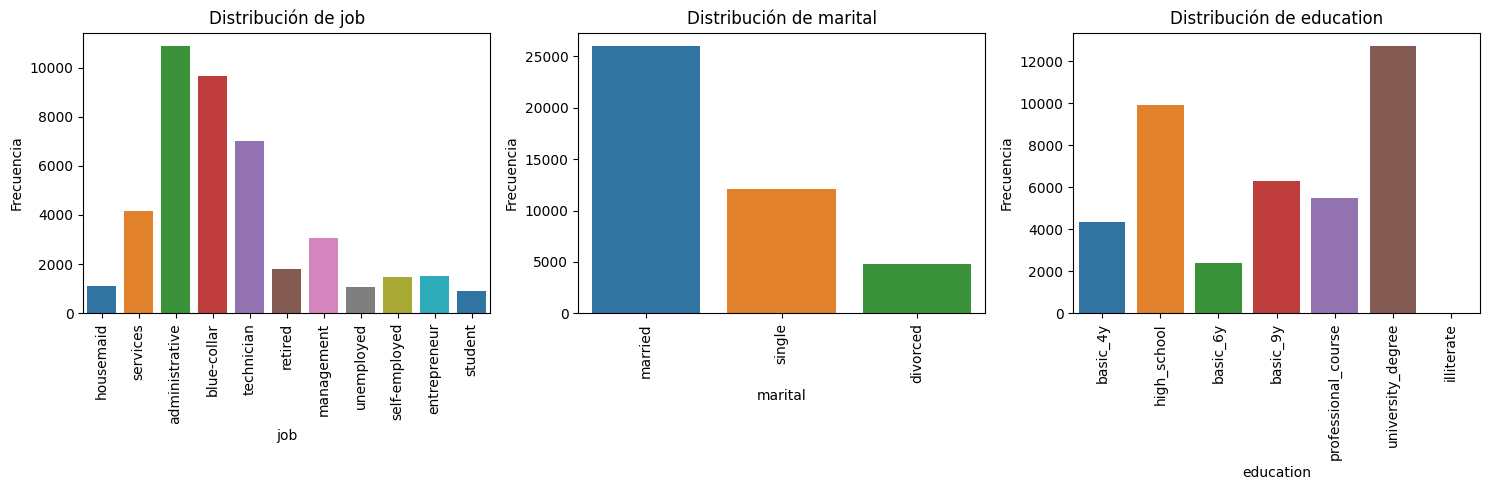

In [110]:
subplot_col_cat(df_nulos)

In [111]:
df.sample(5)


,Unnamed: 0.1,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,...,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_
12749,12749,12846,43.0,administrative,single,high_school,0.0,0.0,0.0,cellular,...,1.4,93.918,-42.7,4.962,5228,no,2015-01-31 00:12:00,35.917,-77.858,b43d5dd4-672d-400a-a93c-77e45a85b0f5
34285,34285,34429,NaN,services,married,high_school,NaN,1.0,0.0,cellular,...,-1.8,92.893,-46.2,1.266,5099,no,2015-01-20 00:02:00,35.584,-106.584,b4a1487a-2873-4452-84de-4a8d0f1273a7
10828,10828,10925,NaN,management,single,basic_9y,0.0,0.0,0.0,telephone,...,1.4,94.465,-41.8,4.962,5228,no,2017-01-05 00:07:00,45.971,-118.595,446d70ab-7f9f-4200-8134-d52d7adc6db1
6719,6719,6816,44.0,blue-collar,single,basic_4y,NaN,0.0,0.0,telephone,...,1.1,93.994,-36.4,4.857,5191,no,2016-01-14 00:02:00,30.364,-71.758,c53c0801-1001-42c1-953e-6497320c7784
33379,33379,33523,59.0,housemaid,divorced,basic_6y,NaN,1.0,0.0,cellular,...,-1.8,92.893,-46.2,1.291,5099,no,2016-01-01 00:02:00,25.962,-105.091,5a70a0c9-c087-4618-adff-27962312680b


Tanto el trabajo, como estado civil y estudios, son nulos en un bajo porcentaje. Haciendo un análisis de los datos se puede comprobar que simplemente no se han aportado por parte del usuario, por lo que podemos sustiutir los nulos por un desconocido.

In [114]:
df.loc[:,df.select_dtypes(include='O').columns] = df.select_dtypes(include='O').fillna('unknown')

In [ ]:
# Outliars

In [116]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unnamed: 0.1,43000.0,21499.5,0.0,10749.75,21499.5,32249.25,42999.0,12413.175124
Unnamed: 0,43000.0,20651.099047,0.0,10381.75,20642.5,30930.25,41187.0,11868.770913
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
default,34019.0,0.000088,0.0,0.0,0.0,0.0,1.0,0.00939
housing,41974.0,0.535998,0.0,0.0,1.0,1.0,1.0,0.498708
loan,41974.0,0.15562,0.0,0.0,0.0,0.0,1.0,0.362499
duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366


In [121]:
def subplot_col_num (dataframe):
    # Seleccionar columnas numéricas
    col_nums = dataframe.select_dtypes(include='number').columns
    num_graph = len(col_nums)

    num_rows = (num_graph +2)//2

    fig, axes = plt.subplots(num_graph, 2, figsize=(15, num_rows * 5))
   
    # Generar gráficos
    for i, col in enumerate(col_nums):
        sns.histplot(data=dataframe, x=col, ax=axes[i,0], bins=200)
        axes[i,0].set_title(f'Distribución de {col}')
        axes[i,0].set_xlabel(col)
        axes[i,0].set_ylabel('Frecuencia')
       
        sns.boxplot(data=dataframe, x=col, ax=axes[i,1])
        axes[i,1].set_title(f'Boxplot de {col}')


    # Eliminar ejes sobrantes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

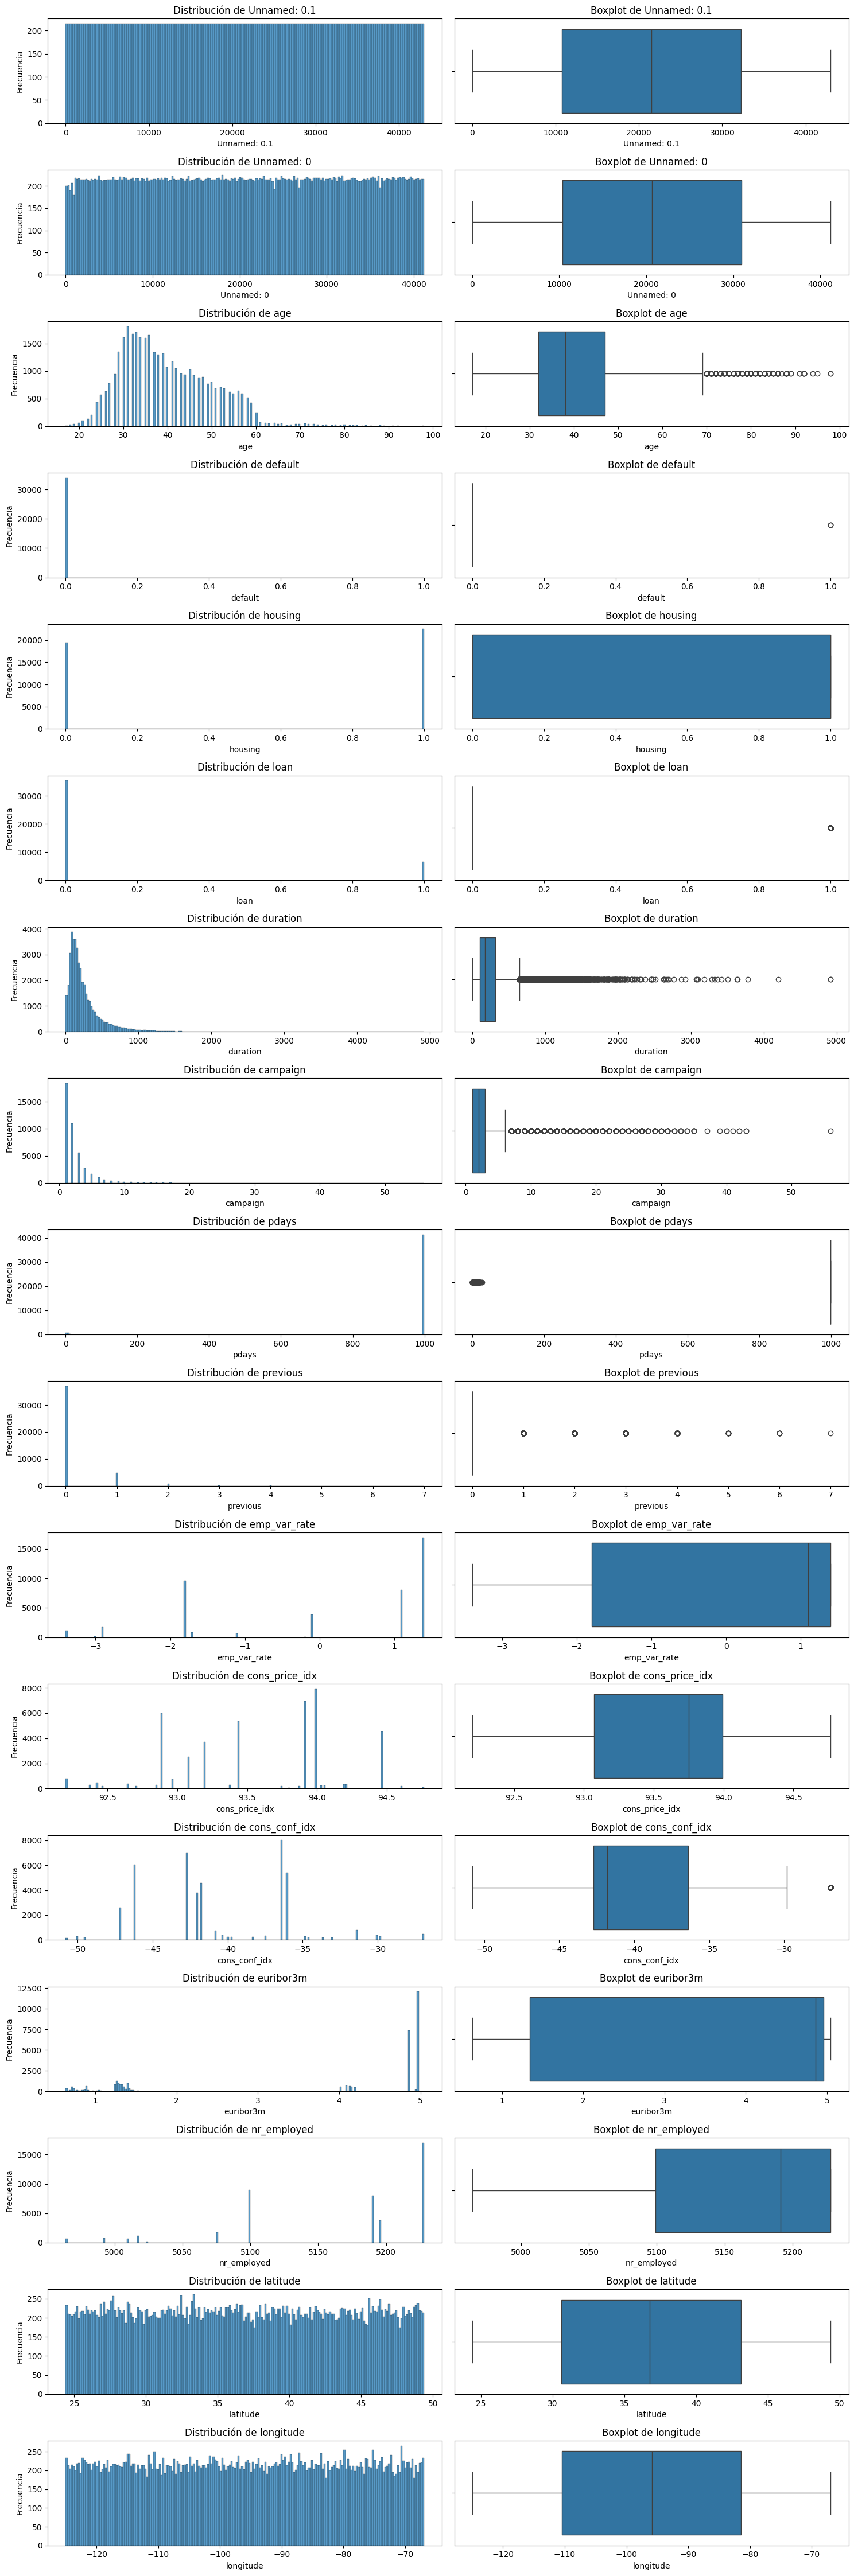

In [122]:
subplot_col_num(df)

- Age Distribución de edad tiene outliers
- Default tiene outliers. Aunque son valores de 0 y 1. Siendo practicamente escaso el valor 1
- Loan tiene outlires. Aunque son valores de 0 y 1, predominando el 0
- Duration tiene outliers. Distribución escasa en valores altos
- Campaign tiene outliers. Parecida distribución que duration
- Pdays tiene outliers. 
- Cons_conf_inx tiene outliers

In [132]:
def calculo_outliers (df, cols):
    for col in cols:
        q_75 = df[col].quantile(0.75)
        q_25 = df[col].quantile(0.25)
        rango_itq = q_75 - q_25
        inferior = q_25 - (rango_itq*1.5)
        superior = q_75 + (rango_itq*1.5)
        outliers = df[(df[col]< inferior) | (df[col]> superior)]
        num_outliers = len(outliers)
        per_outliers = num_outliers/df.shape[0]*100
        
        print(f' en la columna {col.upper()} tenemos un total de {num_outliers} outliers, lo qu representa un {per_outliers}% del total')
        


In [134]:
calculo_outliers(df,['age','default', 'loan', 'duration', 'campaign', 'pdays','cons_conf_idx'])

 en la columna AGE tenemos un total de 441 outliers, lo qu representa un 1.0255813953488373% del total
 en la columna DEFAULT tenemos un total de 3 outliers, lo qu representa un 0.0069767441860465115% del total
 en la columna LOAN tenemos un total de 6532 outliers, lo qu representa un 15.190697674418605% del total
 en la columna DURATION tenemos un total de 3072 outliers, lo qu representa un 7.144186046511628% del total
 en la columna CAMPAIGN tenemos un total de 2504 outliers, lo qu representa un 5.823255813953488% del total
 en la columna PDAYS tenemos un total de 1588 outliers, lo qu representa un 3.6930232558139533% del total
 en la columna CONS_CONF_IDX tenemos un total de 477 outliers, lo qu representa un 1.1093023255813954% del total


# Nulos Numéricas

In [138]:
df_nulos.select_dtypes(include='number').isnull().mean()*100

age               11.906977
default           20.886047
housing            2.386047
loan               2.386047
cons_price_idx     1.095349
euribor3m         21.525581
dtype: float64

Como housing, cons_price_idx y euribor3m no tienen outliers, podemos sustituir los nulos por la media o la moda.

In [139]:
df_nulos.describe().T

,count,mean,min,25%,50%,75%,max,std
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
default,34019.0,0.000088,0.0,0.0,0.0,0.0,1.0,0.00939
housing,41974.0,0.535998,0.0,0.0,1.0,1.0,1.0,0.498708
loan,41974.0,0.15562,0.0,0.0,0.0,0.0,1.0,0.362499
cons_price_idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
euribor3m,33744.0,3.616521,0.634,1.344,4.857,4.961,5.045,1.737117
date,42752,2017-01-16 02:32:41.081586944,2015-01-01 00:01:00,2016-01-09 00:02:00,2017-01-16 00:08:00,2018-01-24 00:03:00,2019-01-31 00:12:00,NaN


In [175]:
df_filled_simple = df.fillna({
                    'housing': df['housing'].median(),
                    'cons_price_idx' : df['cons_price_idx'].mean(),
                    'euribor3m' : df['euribor3m'].median(),
                    'loan' : df['loan'].median()
            
})

In [176]:
df_filled_simple.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
age               5120
job                  0
marital              0
education            0
default           8981
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [177]:
def imputar_iterative(dataframe, lista_columns):
    iter_imputer = IterativeImputer(max_iter=50,
                                    random_state=42)
    data_imputed = iter_imputer.fit_transform(dataframe[lista_columns])
    new_col = [col + "_iterative" for col in lista_columns]
    dataframe[new_col] = data_imputed
    return dataframe

In [178]:
def imputar_knn(dataframe, lista_columns):
    knn_imputer = KNNImputer(n_neighbors=5)
    data_imputed = knn_imputer.fit_transform(dataframe[lista_columns])
    new_col = [col + "_knn" for col in lista_columns]
    dataframe[new_col] = data_imputed
    return dataframe

In [179]:
df_filled_simple = imputar_iterative(df_filled_simple, ['age'])
df_filled_simple.sample()

,Unnamed: 0.1,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,...,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_,age_iterative
18158,18158,18255,35.0,administrative,married,university_degree,0.0,0.0,0.0,cellular,...,93.918,-42.7,4.963,5228,yes,2016-01-27 00:06:00,32.256,-91.474,021445bf-4d0d-42af-88f3-6e9778bbf110,35.0


In [180]:
df_filled_simple = imputar_knn(df_filled_simple, ['age'])
df_filled_simple.sample()

,Unnamed: 0.1,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,...,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_,age_iterative,age_knn
13533,13533,13630,51.0,administrative,married,professional_course,0.0,0.0,0.0,cellular,...,-42.7,4.963,5228,no,2017-01-16 00:12:00,42.697,-95.316,278cc30a-60a4-423a-8547-c9afe6ccea86,51.0,51.0


In [181]:
df_filled_simple.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
age               5120
job                  0
marital              0
education            0
default           8981
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
age_iterative        0
age_knn              0
dtype: int64

In [182]:
df_filled_simple[['age', 'age_iterative','age_knn']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37880.0,39.977112,10.437957,17.0,32.0,38.000000,47.0,98.0
age_iterative,43000.0,39.977112,9.796830,17.0,33.0,39.977112,46.0,98.0
age_knn,43000.0,39.977112,9.796830,17.0,33.0,39.977112,46.0,98.0


In [183]:
df_filled_simple.drop(columns=['age', 'age_iterative'], inplace=True)

In [184]:
df_filled_simple.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
job                  0
marital              0
education            0
default           8981
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
age_knn              0
dtype: int64

In [185]:
df_filled_simple = imputar_iterative(df_filled_simple, ['date'])
df_filled_simple.sample()
df_filled_simple = imputar_knn(df_filled_simple, ['date'])
df_filled_simple.sample()
df_filled_simple[['date', 'date_iterative','date_knn']].describe().T


,count,mean,min,25%,50%,75%,max,std
date,42752,2017-01-16 02:32:41.081586944,2015-01-01 00:01:00,2016-01-09 00:02:00,2017-01-16 00:08:00,2018-01-24 00:03:00,2019-01-31 00:12:00,NaN
date_iterative,43000.0,1422776735791163136.0,-9223372036854775808.0,1452211560000000000.0,1484524980000000000.0,1516752060000000000.0,1548893520000000000.0,812079937642615296.0
date_knn,43000.0,1422776735791163136.0,-9223372036854775808.0,1452211560000000000.0,1484524980000000000.0,1516752060000000000.0,1548893520000000000.0,812079937642615296.0


In [186]:
df_filled_simple.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
job                  0
marital              0
education            0
default           8981
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
age_knn              0
date_iterative       0
date_knn             0
dtype: int64

In [189]:
df_filled_simple.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
job                  0
marital              0
education            0
default           8981
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
age_knn              0
date_iterative       0
date_knn             0
dtype: int64

In [190]:
df_filled_simple = imputar_iterative(df_filled_simple, ['default'])
df_filled_simple.sample()
df_filled_simple = imputar_knn(df_filled_simple, ['default'])
df_filled_simple.sample()
df_filled_simple[['default', 'default_iterative','default_knn']].describe().T

,count,mean,std,min,25%,50%,75%,max
default,34019.0,0.000088,0.009390,0.0,0.0,0.0,0.0,1.0
default_iterative,43000.0,0.000088,0.008352,0.0,0.0,0.0,0.0,1.0
default_knn,43000.0,0.000088,0.008352,0.0,0.0,0.0,0.0,1.0


In [194]:
df_filled_simple.drop(columns=['date', 'date_iterative'], inplace=True)

In [197]:
df_filled_simple.isnull().sum()

Unnamed: 0.1      0
Unnamed: 0        0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
latitude          0
longitude         0
id_               0
age_knn           0
date_knn          0
default_knn       0
dtype: int64

In [201]:
df_filled_simple.to_csv('../data/data_limpios_nonulos.csv', index = False)